In [68]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.utils import mm_to_inches

plt.rc("font", family="Arial")

# Parameters
FE_DIR = "./results/7.6-Effect_models/meg_llm_model_outputs"
ENT_DIR = "./results/7.4-Feature_Extraction/llm_consensus_outputs"
SEED = 1016

In [88]:
def _zscore(s):
    """
    Parameters
    ----------
    s: pd.Series

    Returns
    -------
    pd.Series
    """
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd


def _safe_sem_ci(values):
    """
    Return mean and approximate 95% CI half-width.
    """
    values = pd.Series(values).dropna().astype(float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return values.iloc[0], 0.0
    return values.mean(), 1.96 * values.sem(ddof=1)


def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "n.s."


def p_label(p):
    if pd.isna(p):
        return ""
    if p < 1e-4:
        return "$p < 1e-4$"
    if p < 0.001:
        return "$p < .001$"
    if p < 0.01:
        return f"$p = {p:.3f}$"
    if p < 0.05:
        return f"$p = {p:.3f}$"
    return f"$p = {p:.3f}$"


def get_term(fe, model, term):
    row = fe[(fe["model"] == model) & (fe["term"] == term)]
    if row.empty:
        raise KeyError(f"Missing coefficient: {model} / {term}")
    return row.iloc[0]


def load_fixed_effects(data_dir):
    fe_path = os.path.join(data_dir, "all_fixed_effects_compact.csv")
    if os.path.exists(fe_path):
        return pd.read_csv(fe_path)
    else:
        raise ValueError(f"File not exists: {fe_path}")


def load_entropy_condition_data(data_dir):
    stim_path = os.path.join(data_dir, "stim_llm_consensus_features.csv")

    groups = [
        ("Conj. Consistent", ["STA", "DevSem"]),
        ("Conj. Conflict", ["DevSynC1", "DevSynC2"]),
    ]

    if os.path.exists(stim_path):
        stim = pd.read_csv(stim_path)
        if "CandidateEntropy_z" not in stim.columns:
            stim["CandidateEntropy_z"] = _zscore(stim["Consensus_CandidateEntropy"])
        out = []
        for group_name, members in groups:
            vals = stim.loc[stim["Condition"].isin(members), "CandidateEntropy_z"].dropna().values
            out.append({
                "Condition": group_name,
                "members": members,
                "mean": float(np.mean(vals)),
                "sem": float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0,
                "values": vals,
                "raw": True,
            })
        return out
    else:
        raise ValueError(f"File not exists: {stim_path}")


def forest(ax, fe, model, terms, labels, color, xlim, highlight_terms=None):
    highlight_terms = set(highlight_terms or [])
    rows = [get_term(fe, model, t) for t in terms]
    est = np.array([r["estimate"] for r in rows], dtype=float)
    se = np.array([r["se"] for r in rows], dtype=float)
    p = np.array([r["pvalue"] for r in rows], dtype=float)
    ci = 1.96 * se
    y = np.arange(len(labels))[::-1]

    ax.set_xlim(*xlim)
    ax.axvline(0, color="0.78", lw=1.0, zorder=0)

    for yi, term, e, c, pp in zip(y, terms, est, ci, p):
        active = (pp < 0.05) or (term in highlight_terms)
        col = color if active else "0.62"
        alpha = 1.0 if active else 0.75
        ax.errorbar(e, yi, xerr=c, fmt="o", color=col, ecolor=col,
                    elinewidth=1.25, capsize=2.5, markersize=4.6, alpha=alpha, zorder=3)
        ax.text(xlim[1] - 0.006 * (xlim[1] - xlim[0]), yi, 
                f"( {convert_pvalue_to_asterisks(pp)} )",
                ha="right", va="center", fontsize=7, fontweight="bold", color="black" if active else "0.55")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7, fontweight="bold")
    ax.set_xlabel(f"Standardized $\\beta$", fontsize=7, fontweight="bold")
    ax.tick_params(axis="x", labelsize=6)
    ax.grid(axis="x", color="0.93", lw=0.8)

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

In [6]:
# Load Data
fe = load_fixed_effects(FE_DIR)
ent_data = load_entropy_condition_data(ENT_DIR)

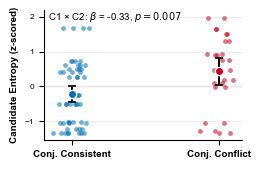

In [96]:
# Panel A
colors = {"Conj. Consistent": "#0072b2", "Conj. Conflict": "#C10020"}

fig, ax = plt.subplots(1, 1, figsize=mm_to_inches(65, 43))

rng = np.random.default_rng(SEED)
for i, d in enumerate(ent_data):
    cond = d["Condition"]
    col = colors[cond]
    if len(d["values"]) > 0:
        vals = np.asarray(d["values"])
        jitter = rng.normal(0, 0.055, len(vals))
        jitter = np.clip(jitter, -0.13, 0.13)
        ax.scatter(i + jitter, vals, s=12, color=col, alpha=0.55, linewidths=0, zorder=2)
    mean, ci95 = _safe_sem_ci(vals)
    ax.errorbar(i, mean, yerr=ci95, fmt="o", ms=6,
                    color=col, ecolor="black", 
                    markeredgecolor="white",
                    elinewidth=1.45, capthick=1.2, capsize=2.6, zorder=5)

ax.axhline(0, color="0.78", lw=1.0, zorder=1)
ax.grid(axis="y", color="0.92", lw=0.65, zorder=0)

ax.set_xticks(np.arange(len(ent_data)))
ax.set_xticklabels([d["Condition"] for d in ent_data], fontsize=7, fontweight="bold")
ax.set_ylabel("Candidate Entropy (z-scored)", fontsize=7, fontweight="bold")
ax.tick_params(axis="y", labelsize=6)

ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.set_ylim(-1.55, 2.20)

r = get_term(fe, "entropy_structure_ols", "C1Type:C2Type")
ax.text(0.02, 1, f"C1 × C2: $\\beta$ = {r['estimate']:.2f}, {p_label(r['pvalue'])}",
            transform=ax.transAxes, va="top", fontsize=7)

plt.savefig("./images/effect_models_A.svg", transparent=True, dpi=600, format="svg", bbox_inches="tight")
plt.show()

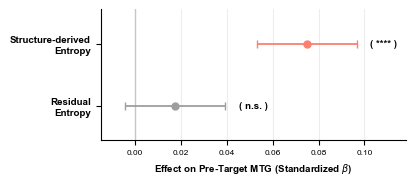

In [81]:
# Panel B
fig, ax = plt.subplots(1, 1, figsize=mm_to_inches(100, 43))

terms_b = ["Entropy_struct_component_z", "Entropy_residual_component_z"]
labels_b = ["Structure-derived\nEntropy", "Residual\nEntropy"]
rows = [get_term(fe, "pre_MTG_entropy_structural_vs_residual", t) for t in terms_b]
est = np.array([r["estimate"] for r in rows], dtype=float)
se = np.array([r["se"] for r in rows], dtype=float)
p = np.array([r["pvalue"] for r in rows], dtype=float)
y = np.array([1, 0])

ax.set_xlim(-0.015, 0.118)
ax.axvline(0, color="0.78", lw=1.0)
for yi, e, s, pp, col in zip(y, est, se, p, ["salmon", "0.62"]):
    ax.errorbar(e, yi, xerr=1.96 * s, fmt="o", color=col, ecolor=col,
                    ms=5, elinewidth=1.3, capsize=3)
    ax.text(e + 1.96 * s + 0.006, yi, f"( {convert_pvalue_to_asterisks(pp)} )", 
            va="center", fontsize=7, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(labels_b, fontsize=7, fontweight="bold")
ax.set_ylim(-0.55, 1.55)
ax.set_xlabel(f"Effect on Pre-Target MTG (Standardized $\\beta$)", fontsize=7, fontweight="bold")
ax.tick_params(axis="x", labelsize=6)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.grid(axis="x", color="0.93", lw=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("./images/effect_models_B.svg", transparent=True, dpi=600, format="svg", bbox_inches="tight")
plt.show()

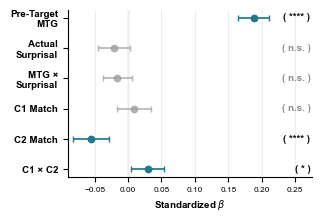

In [99]:
# Panel C
fig, ax = plt.subplots(1, 1, figsize=mm_to_inches(80, 55))

terms = [
        "Pre_MTG_LH_amp_z",
        "LLM_ActualSurprisal_z",
        "Pre_MTG_LH_amp_z:LLM_ActualSurprisal_z",
        "C1_match",
        "C2_match",
        "C1_match:C2_match",
    ]
labels = ["Pre-Target\nMTG", 
          "Actual\nSurprisal", 
          "MTG ×\nSurprisal", 
          "C1 Match", 
          "C2 Match", 
          "C1 × C2"]
forest(ax, fe, "post_MidTL_main", terms, labels, "#1F7A8C", (-0.09, 0.275))

plt.savefig("./images/effect_models_C.svg", transparent=True, dpi=600, format="svg", bbox_inches="tight")
plt.show()

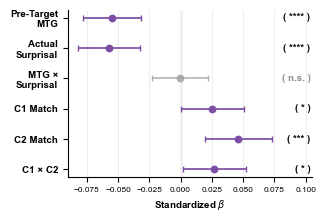

In [100]:
# Panel D
fig, ax = plt.subplots(1, 1, figsize=mm_to_inches(80, 55))

forest(ax, fe, "post_ATL_main", terms, labels, "#7B4EA3", (-0.09, 0.105))

plt.savefig("./images/effect_models_D.svg", transparent=True, dpi=600, format="svg", bbox_inches="tight")
plt.show()